In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Pittsburgh's Best Neighborhood Combined Analysis

**Team:** Lucky Number Seven

---

## Introduction

Our team defined the "best" neighborhood in Pittsburgh as one that balances three different metrics from **quality of life, safety to accessibility**. 

Using the following datasets: <br>
[City of Pittsburgh Parks](https://data.wprdc.org/dataset/parks1) | <br>
[Pittsburgh Police Arrests 2024–2026](https://data.wprdc.org/dataset/pbp_arrest_data_2024_2025) | <br>
[Pittsburgh Regional Transit Stops](https://data.wprdc.org/dataset/prt-of-allegheny-county-transit-stops) | <br>

This notebook combines all three sub-metrics into a single ranking and names the overall best neighborhood in Pittsburgh.

## Method

Each sub-metric is normalized to a 0-1 scale (1 being best and 0 being worst). To get a single overall score per neighborhood, we average the three sub-metric scores with equal weights:

$$\text{overall score} = \frac{1}{3}(\text{green} + \text{safety} + \text{accessibility})$$

In [79]:
#quality scores
green = pd.read_csv('green_space_scores_by_neighborhood.csv')
print(f'Green-space scores: {len(green)} neighborhoods')



Green-space scores: 79 neighborhoods


In [80]:
#safety scores
safety = pd.read_csv('safety_scores.csv')
print(f'Safety scores: {len(safety)} neighborhoods')

name_fixes = {'St. Clair': 'Saint Clair', 'Southshore': 'South Shore', 'Lincoln–Lemington–Belmar': 'Lincoln-Lemington-Belmar',
    'Spring Hill–City View': 'Spring Hill-City View',}
safety['neighborhood'] = safety['neighborhood'].replace(name_fixes)

safety_clean = (safety.groupby('neighborhood', as_index = False)['arrest_count'].sum())

min_arr = safety_clean['arrest_count'].min()
max_arr = safety_clean['arrest_count'].max()
safety_clean['safety_score'] = (1 - (safety_clean['arrest_count'] - min_arr) / (max_arr - min_arr)).round(3)

safety_clean = safety_clean.sort_values('safety_score', ascending = False).reset_index(drop = True)
safety_clean.head()

Safety scores: 95 neighborhoods


,neighborhood,arrest_count,safety_score
0,Chartiers City,4,1.000
1,Swisshelm Park,17,0.998
2,Ridgemont,17,0.998
3,Chartiers,23,0.997
4,Regent Square,24,0.997


In [81]:
accessibility = pd.read_csv('neighborhood_accessibility_scores.csv')
print(f'Accessibility Scores: {len(accessibility)} neighborhoods')

Accessibility Scores: 89 neighborhoods


## Merge All Three Sub-Metrics


In [ ]:
combined = safety_clean[['neighborhood', 'safety_score']].copy()

# Merge green space
combined = combined.merge(
    green[['neighborhood', 'green_score']],
    on='neighborhood',
    how='inner'
)

# Merge accessibility
combined = combined.merge(
    accessibility[['hood', 'accessibility_score']],
    left_on='neighborhood',
    right_on='hood',
    how='inner'
)

# Drop duplicate column
combined = combined.drop(columns=['hood'])

print(f'Combined table: {len(combined)} neighborhoods')
combined.head()

,neighborhood,safety_score,divname,green_score,total_acreage,accessibility_score
0,Chartiers City,1.000,Emerald,0.00,413.05,0.019
1,Swisshelm Park,0.998,Frick,0.62,847.53,0.010
2,Ridgemont,0.998,Emerald,0.00,413.05,0.000
3,Regent Square,0.997,Frick,0.62,847.53,0.055
4,New Homestead,0.996,McKinley,1.00,1114.11,0.010


In [83]:
score_cols = ['safety_score', 'green_score', 'accessibility_score']
for col in score_cols:
    print(combined.columns.tolist())
    n_have = combined[col].notna().sum()
    print(f'{col:20s}: {n_have} / {len(combined)} neighborhoods have a score')

['neighborhood', 'safety_score', 'divname', 'green_score', 'total_acreage', 'accessibility_score']
safety_score        : 74 / 74 neighborhoods have a score
['neighborhood', 'safety_score', 'divname', 'green_score', 'total_acreage', 'accessibility_score']
green_score         : 74 / 74 neighborhoods have a score
['neighborhood', 'safety_score', 'divname', 'green_score', 'total_acreage', 'accessibility_score']
accessibility_score : 74 / 74 neighborhoods have a score


## Compute the Overall Score 

To Find "Best" Neighborhood by averaging the sub-metric scores per neighborhood. Neighborhoods missing one or more scores are averaged over only the scores they do have.

In [84]:
available_cols = [c for c in score_cols if combined[c].notna().any()]

combined['n_metrics'] = combined[available_cols].notna().sum(axis = 1)
combined['overall_score'] = combined[available_cols].mean(axis = 1, skipna = True)

max_metrics = combined['n_metrics'].max()
ranked = combined[combined['n_metrics'] == max_metrics].copy()
ranked = ranked.sort_values('overall_score', ascending = False).reset_index(drop = True)

print(f'Ranking based on {max_metrics} sub-metrics, across {len(ranked)} neighborhoods.')
ranked.head(15)

Ranking based on 3 sub-metrics, across 74 neighborhoods.


,neighborhood,safety_score,divname,green_score,total_acreage,accessibility_score,n_metrics,overall_score
0,South Shore,0.971,McKinley,1.000,1114.11,0.216,3,0.729000
1,Beltzhoover,0.961,McKinley,1.000,1114.11,0.204,3,0.721667
2,South Side Slopes,0.927,McKinley,1.000,1114.11,0.221,3,0.716000
3,Lincoln Place,0.977,McKinley,1.000,1114.11,0.121,3,0.699333
4,Overbrook,0.969,McKinley,1.000,1114.11,0.104,3,0.691000
5,Carrick,0.785,McKinley,1.000,1114.11,0.254,3,0.679667
6,Bon Air,0.974,McKinley,1.000,1114.11,0.061,3,0.678333
7,Allentown,0.916,McKinley,1.000,1114.11,0.104,3,0.673333
8,Hays,0.988,McKinley,1.000,1114.11,0.024,3,0.670667
9,New Homestead,0.996,McKinley,1.000,1114.11,0.010,3,0.668667


## The Best Neighborhood

In [85]:
winner = ranked.iloc[0]
print(f"Best Neighborhood: {winner['neighborhood']}")
print()
print(f"metrics:")
print(f"Overall score: {winner['overall_score']:.2f}")
print(f"Safety score: {winner['safety_score']:.2f}")
print(f"Green space score: {winner['green_score']:.2f}")
print(f"Accessibility score: {winner['accessibility_score']:.2f}")

Best Neighborhood: South Shore

metrics:
Overall score: 0.73
Safety score: 0.97
Green space score: 1.00
Accessibility score: 0.22


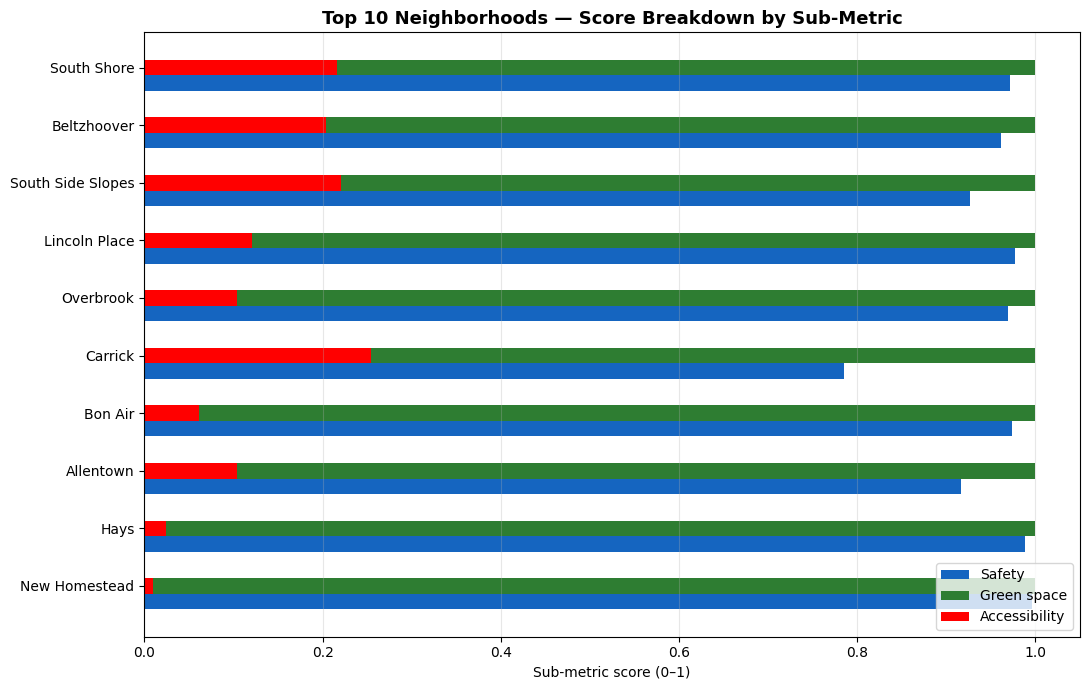

In [86]:
top10 = ranked.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(top10))
width = 0.27

ax.barh(y - width, top10['safety_score'], width, label = 'Safety', color = '#1565C0')
ax.barh(y,        top10['green_score'],  width, label = 'Green space', color = '#2E7D32')
ax.barh(y,        top10['accessibility_score'],  width, label='Accessibility', color='red')

ax.set_yticks(y)
ax.set_yticklabels(top10['neighborhood'])
ax.set_xlabel('Sub-metric score (0–1)')
ax.set_xlim(0, 1.05)
ax.set_title('Top 10 Neighborhoods — Score Breakdown by Sub-Metric', fontsize = 13, fontweight = 'bold')
ax.legend(loc = 'lower right')
ax.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.show()

In [87]:
ranked.to_csv('final_rankings.csv', index=False)
print(f'Saved final_rankings.csv with {len(ranked)} ranked neighborhoods.')

Saved final_rankings.csv with 74 ranked neighborhoods.


### Limitations

> Geographic mismatch - The parks dataset only labels parks by maintenance division, so it requires mapping each division's score to its respective neighborhoods. This means every neighborhood within the same division receives the same green space score, even though in reality a neighborhood right next to a regional park has very different access than one on the division's edge. <br>

> Snapshot data - Arrest data covers 2024 to early 2026, parks data is a current snapshot. A one-year window can be biased by short-term spikes. <br>

> **Arrests ≠ crime - Arrest counts measure police activity, not crime itself. A heavily-policed neighborhood may show more arrests not because it's less safe but because it gets more attention.